In [1]:
# Cell 1 — setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import BRONZE_DIR, SILVER_DIR
from data.timetable import (
    add_segment_type,
    add_dynamics,
    add_period,
    add_time_in_seconds,
    add_train_type,
)

DISTRIBUTIONS_DIR = Path.cwd().parent / 'data' / 'distributions'
DISTRIBUTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Grens disturbance vs disruption
# Rijtijden buiten [PLANNED * MIN_FACTOR, PLANNED * MAX_FACTOR] worden als disruption beschouwd
MIN_FACTOR = 0.3   # rijtijd minder dan 30% van gepland → disruption
MAX_FACTOR = 3.0   # rijtijd meer dan 300% van gepland → disruption

In [2]:
# Cell 2 — laad brons
bronze_files = sorted(BRONZE_DIR.glob('*.parquet'))
df = pd.concat([pd.read_parquet(f) for f in bronze_files], ignore_index=True)
print(f"{df['DATDEP'].nunique()} dagen, {df['TRAIN_NO'].nunique()} treinen, {len(df)} rijen")
print(f"Datumrange: {df['DATDEP'].min()} → {df['DATDEP'].max()}")

260 dagen, 1365 treinen, 2618072 rijen
Datumrange: 2025-03-03 00:00:00 → 2026-02-27 00:00:00


In [3]:
# Cell 3 — verrijking (geen aggregatie, alle dagen behouden)
# assign_platforms wordt NIET toegepast: platformtoewijzing is een eigenschap
# van de geplande timetable, niet van individuele observaties.
# SECTION blijft zonder platform suffix — rijtijden worden gemeten per fysieke sectie.
df['LINE_NO_DEP'] = df['LINE_NO_DEP'].str.replace('/', '-')
dwell_mask = df['SOURCE'] == df['TARGET']
df['SECTION'] = np.where(
    dwell_mask,
    df['SOURCE'].astype(str),
    df['LINE_NO_DEP'].astype(str) + ':' + df['SOURCE'].astype(str) + '-' + df['TARGET'].astype(str)
)

df = add_segment_type(df)    # vereist PLANNED_ENTRY/EXIT als datetime, vóór add_time_in_seconds
df = add_period(df)          # vereist PLANNED_EXIT als datetime, vóór add_time_in_seconds
df = add_time_in_seconds(df) # converteert PLANNED_ENTRY/EXIT naar ENTRY/EXIT_SECONDS
df = add_dynamics(df)        # vereist TYPE en ENTRY_SECONDS
df = add_train_type(df)      # vereist RELATION_DIRECTION

df = df[df['TYPE'] != 'WITHIN-STATION-PASSING']

print(f"{df['SECTION'].nunique()} unieke secties, {len(df)} observaties")
print(f"Dynamics:   {df['DYNAMICS'].value_counts().to_dict()}")
print(f"Periodes:   {df['PERIOD'].value_counts().to_dict()}")
print(f"Traintypes: {df['TRAIN_TYPE'].value_counts().to_dict()}")

122 unieke secties, 2072118 observaties
Dynamics:   {'0-0': 889695, 'ACC-0': 554997, '0-BR': 553564, 'ACC-BR': 73862}
Periodes:   {'DAYTIME': 833634, 'EVENING': 459201, 'EVENING PEAK': 361235, 'MORNING PEAK': 343418, 'NIGHT': 74630}
Traintypes: {'IC': 1254018, 'L': 549364, 'S': 155694, 'EURST': 52505, 'INT': 37862, 'ICE': 22662, 'TGV': 13}


In [4]:
# Cell 4 — bereken rijtijden in seconden
df['RUNNING_TIME_PLANNED'] = df['EXIT_SECONDS'] - df['ENTRY_SECONDS']

# Werkelijke rijtijd: REAL_ENTRY <= REAL_EXIT altijd (geen swap nodig)
df['REAL_ENTRY'] = pd.to_datetime(df['REAL_ENTRY'])
df['REAL_EXIT']  = pd.to_datetime(df['REAL_EXIT'])

df['RUNNING_TIME_REAL'] = (df['REAL_EXIT'] - df['REAL_ENTRY']).dt.total_seconds()

n_before = len(df)
df = df.dropna(subset=['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED'])
df = df[df['RUNNING_TIME_REAL']    > 0]
df = df[df['RUNNING_TIME_PLANNED'] > 0]
print(f"{n_before - len(df)} rijen verwijderd")
print(f"{len(df)} observaties beschikbaar")

2107 rijen verwijderd
2070011 observaties beschikbaar


=== Rijtijdstatistieken ===
       RUNNING_TIME_REAL  RUNNING_TIME_PLANNED
count          2070011.0             2070011.0
mean               145.3                 141.2
std                 90.5                  98.6
min                  1.0                   1.0
25%                 92.0                 120.0
50%                125.0                 120.0
75%                170.0                 180.0
max              17158.0               86650.0

Ratio werkelijk/gepland:
count    2070011.000
mean           1.118
std            0.947
min            0.003
25%            0.808
50%            1.017
75%            1.226
max          713.000
Name: RT_RATIO, dtype: float64

Ratio < 0.3 (te snel): 1366
Ratio > 3.0 (te traag): 24770


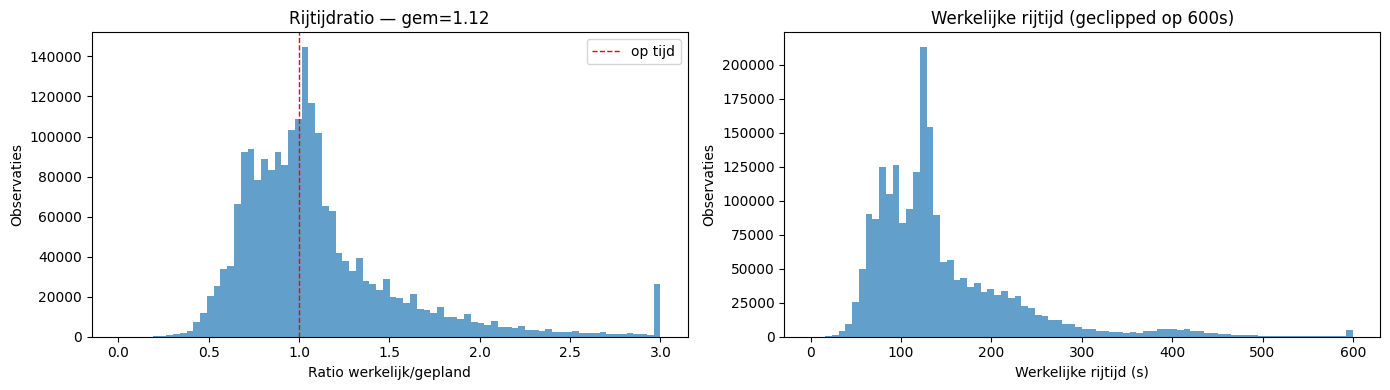

In [5]:
# Cell 5 — validatie rijtijden
print("=== Rijtijdstatistieken ===")
print(df[['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED']].describe().round(1))

df['RT_RATIO'] = df['RUNNING_TIME_REAL'] / df['RUNNING_TIME_PLANNED']
print(f"\nRatio werkelijk/gepland:")
print(df['RT_RATIO'].describe().round(3))
print(f"\nRatio < {MIN_FACTOR} (te snel): {(df['RT_RATIO'] < MIN_FACTOR).sum()}")
print(f"Ratio > {MAX_FACTOR} (te traag): {(df['RT_RATIO'] > MAX_FACTOR).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['RT_RATIO'].clip(0, 3), bins=80, edgecolor='none', alpha=0.7)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1, label='op tijd')
axes[0].set_xlabel('Ratio werkelijk/gepland')
axes[0].set_ylabel('Observaties')
axes[0].set_title(f'Rijtijdratio — gem={df["RT_RATIO"].mean():.2f}')
axes[0].legend()

axes[1].hist(df['RUNNING_TIME_REAL'].clip(0, 600), bins=80, edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Werkelijke rijtijd (s)')
axes[1].set_ylabel('Observaties')
axes[1].set_title('Werkelijke rijtijd (geclipped op 600s)')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — filter disruptions
n_before = len(df)
df_dist = df[
    (df['RT_RATIO'] >= MIN_FACTOR) &
    (df['RT_RATIO'] <= MAX_FACTOR)
].copy()
print(f"{n_before - len(df_dist)} observaties verwijderd als disruption")
print(f"{len(df_dist)} observaties behouden ({100*len(df_dist)/n_before:.1f}% van totaal)")

26136 observaties verwijderd als disruption
2043875 observaties behouden (98.7% van totaal)


In [7]:
# Cell 7 — distributies opbouwen
# Structuur: distributions[section][train_type][dynamics][period]
#   → { 'real': [float, ...], 'n': int }
distributions = {}
n_cells = 0

for (section, train_type, dynamics, period), group in df_dist.groupby(
    ['SECTION', 'TRAIN_TYPE', 'DYNAMICS', 'PERIOD']
):
    real_values = group['RUNNING_TIME_REAL'].dropna().round(1).sort_values().tolist()

    if not real_values:
        continue

    distributions \
        .setdefault(section, {}) \
        .setdefault(train_type, {}) \
        .setdefault(dynamics, {})[period] = {
            'real': real_values,
            'n':    len(real_values),
        }
    n_cells += 1

print(f"Cellen opgeslagen: {n_cells}")
print(f"Unieke secties:    {len(distributions)}")

Cellen opgeslagen: 2457
Unieke secties:    100


In [8]:
# Cell 8 — opslaan
output_path = DISTRIBUTIONS_DIR / 'running_distributions.json'
with open(output_path, 'w') as f:
    json.dump(distributions, f)
size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"Opgeslagen: {output_path} ({size_mb:.2f} MB)")

Opgeslagen: /Users/ddw/Desktop/Rescheduling/data/distributions/running_distributions.json (13.13 MB)


Voorbeeldcel: 0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES | EURST | 0-0 | DAYTIME
  n=2513
  real (eerste 10): [63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0]


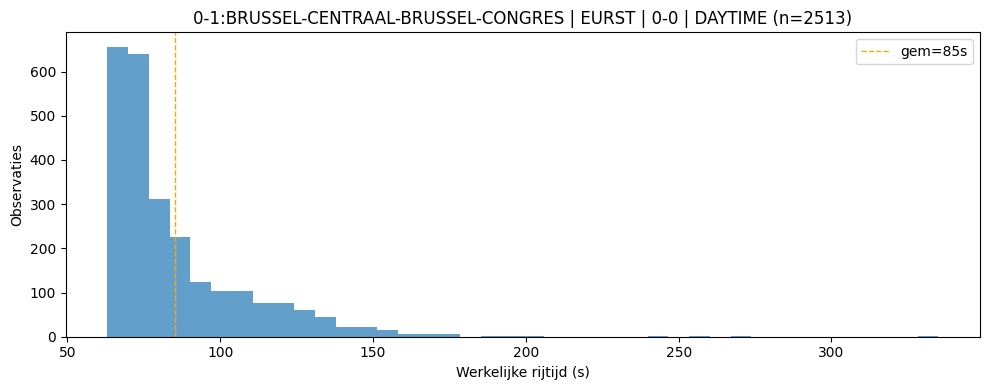

In [9]:
# Cell 9 — validatie output
with open(DISTRIBUTIONS_DIR / 'running_distributions.json') as f:
    loaded = json.load(f)

example_section    = next(iter(loaded))
example_train_type = next(iter(loaded[example_section]))
example_dynamics   = next(iter(loaded[example_section][example_train_type]))
example_period     = next(iter(loaded[example_section][example_train_type][example_dynamics]))
example_cell       = loaded[example_section][example_train_type][example_dynamics][example_period]

print(f"Voorbeeldcel: {example_section} | {example_train_type} | {example_dynamics} | {example_period}")
print(f"  n={example_cell['n']}")
print(f"  real (eerste 10): {example_cell['real'][:10]}")

real_vals = np.array(example_cell['real'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(real_vals, bins=40, edgecolor='none', alpha=0.7)
ax.axvline(float(np.mean(real_vals)), color='orange', linestyle='--', linewidth=1,
           label=f'gem={np.mean(real_vals):.0f}s')
ax.set_xlabel('Werkelijke rijtijd (s)')
ax.set_ylabel('Observaties')
ax.set_title(
    f'{example_section} | {example_train_type} | {example_dynamics} | {example_period} (n={len(real_vals)})'
)
ax.legend()
plt.tight_layout()
plt.show()